# Lab Assignment 2

**Course Name:** Data Analysis and Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

df = pd.read_csv("earthquake_1995-2023.csv")
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M', errors='coerce')
df['year'] = df['date_time'].dt.year
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,year
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu,2023
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN,2023
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,2023
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN,2023
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN,2023


# 1.Bar Plot

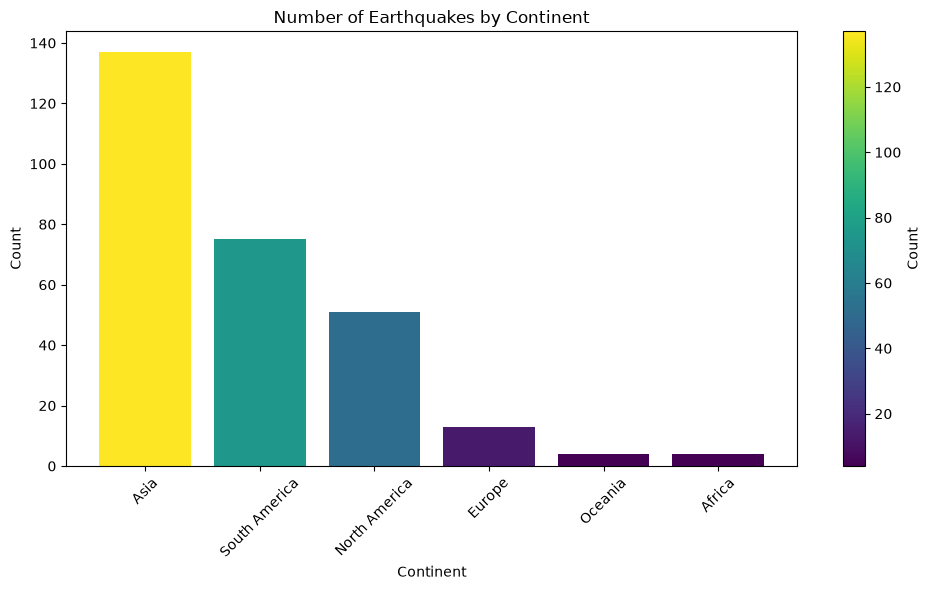

continent
Asia             137
South America     75
North America     51
Europe            13
Oceania            4
Africa             4
Name: count, dtype: int64


In [3]:
continent_counts = df['continent'].value_counts()
norm = mcolors.Normalize(vmin=continent_counts.min(), vmax=continent_counts.max())
colors = cm.viridis(norm(continent_counts.values))

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(continent_counts.index, continent_counts.values, color=colors)
ax.set_title('Number of Earthquakes by Continent')
ax.set_xlabel('Continent')
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=45)

sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Count')

plt.tight_layout()
plt.savefig('bar_continent.png', dpi=300, bbox_inches='tight')
plt.show()

print(continent_counts)

**Conclusion:** Earthquake occurrence is not evenly distributed across continents. Certain continents (typically Asia and the Americas, which lie along the Pacific "Ring of Fire") record significantly higher earthquake counts than others, reflecting their position along major tectonic plate boundaries.

*Note: Rows with missing continent data (NaN) were automatically excluded from this count, so totals do not sum to the full dataset size.*

# 2.Histogram

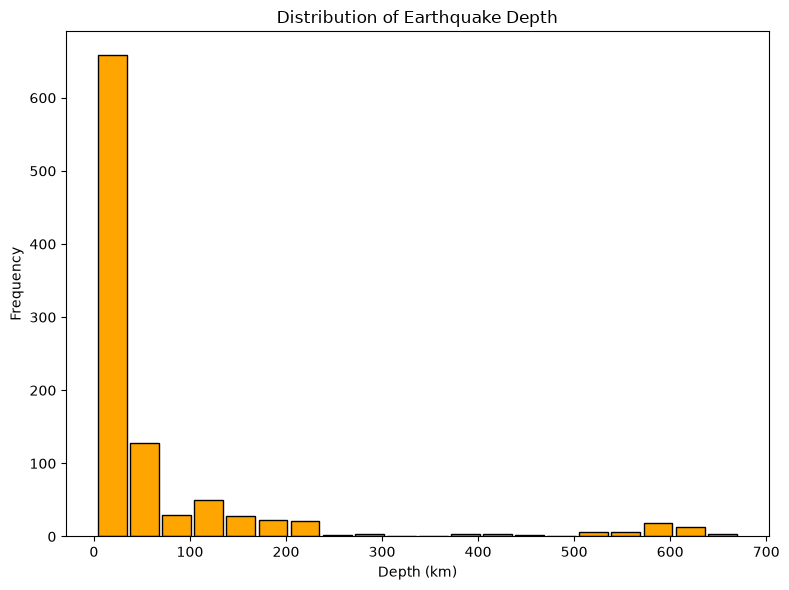

Number of bins: 20
Bin width: 33.41 km
Frequency per bin: [658. 128.  30.  50.  28.  23.  21.   2.   3.   0.   1.   3.   3.   2.
   1.   6.   6.  19.  13.   3.]


In [4]:
plt.figure(figsize=(8,6))
n, bins_edges, patches = plt.hist(df['depth'].dropna(), bins=20, color='orange',
                                    edgecolor='black', rwidth=0.9)
plt.title('Distribution of Earthquake Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('histogram_depth.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Number of bins: {len(bins_edges)-1}")
print(f"Bin width: {bins_edges[1] - bins_edges[0]:.2f} km")
print(f"Frequency per bin: {n}")

**Conclusion:** The distribution is heavily right-skewed — the majority of earthquakes occur at shallow depths (under ~40 km), with frequency dropping sharply as depth increases. A small secondary cluster appears around 550–650 km, consistent with deep-focus earthquakes in specific subduction zones.

# 3.Pie Chart

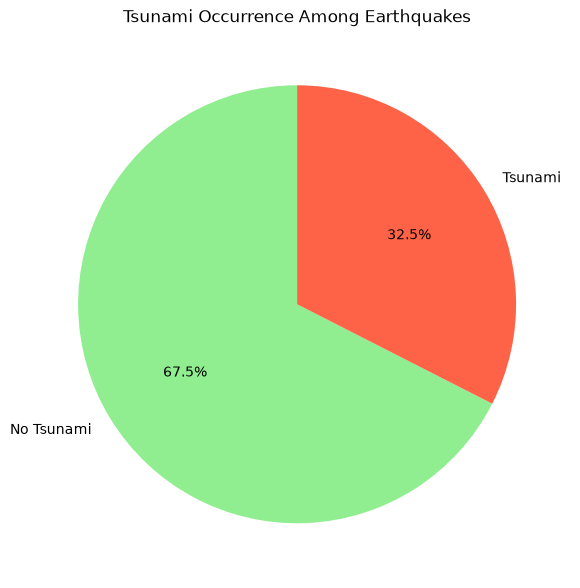

tsunami
0    675
1    325
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6,6))
tsunami_counts = df['tsunami'].value_counts()
plt.pie(tsunami_counts, labels=['No Tsunami','Tsunami'], autopct='%1.1f%%',
        colors=['lightgreen','tomato'], startangle=90)
plt.title('Tsunami Occurrence Among Earthquakes')
plt.tight_layout()
plt.savefig('pie_tsunami.png', dpi=300, bbox_inches='tight')
plt.show()

print(tsunami_counts)

**Conclusion:** Only a small proportion of earthquakes in the dataset triggered a tsunami. This indicates that most seismic events, even significant ones, do not generate tsunamis — which typically require specific conditions like shallow depth and undersea, vertical fault movement.

# 4.Scatter Plot

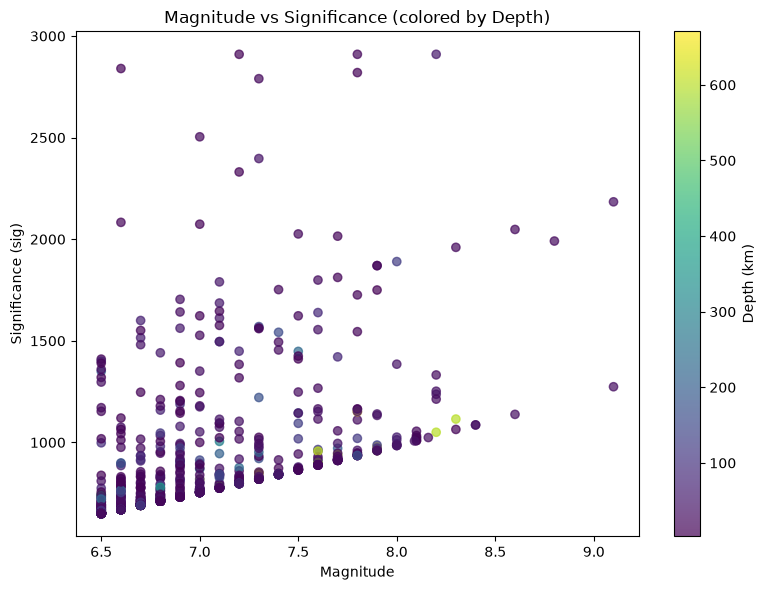

Correlation between Magnitude and Significance: 0.51


In [6]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['magnitude'], df['sig'], c=df['depth'], cmap='viridis', alpha=0.7)
plt.title('Magnitude vs Significance (colored by Depth)')
plt.xlabel('Magnitude')
plt.ylabel('Significance (sig)')
cbar = plt.colorbar(scatter)
cbar.set_label('Depth (km)')
plt.tight_layout()
plt.savefig('scatter_magnitude_sig.png', dpi=300, bbox_inches='tight')
plt.show()

correlation = df['magnitude'].corr(df['sig'])
print(f"Correlation between Magnitude and Significance: {correlation:.2f}")

**Conclusion:** There is a clear positive relationship between magnitude and significance — as magnitude increases, the significance score rises sharply, confirming that significance is largely driven by earthquake strength. The colormap shows no strong pattern between depth and this relationship, meaning high-significance events occur at both shallow and deep levels.

*The correlation coefficient between magnitude and significance is approximately 0.51, confirming a moderate-to-strong positive relationship.*

# 5.Line Plot

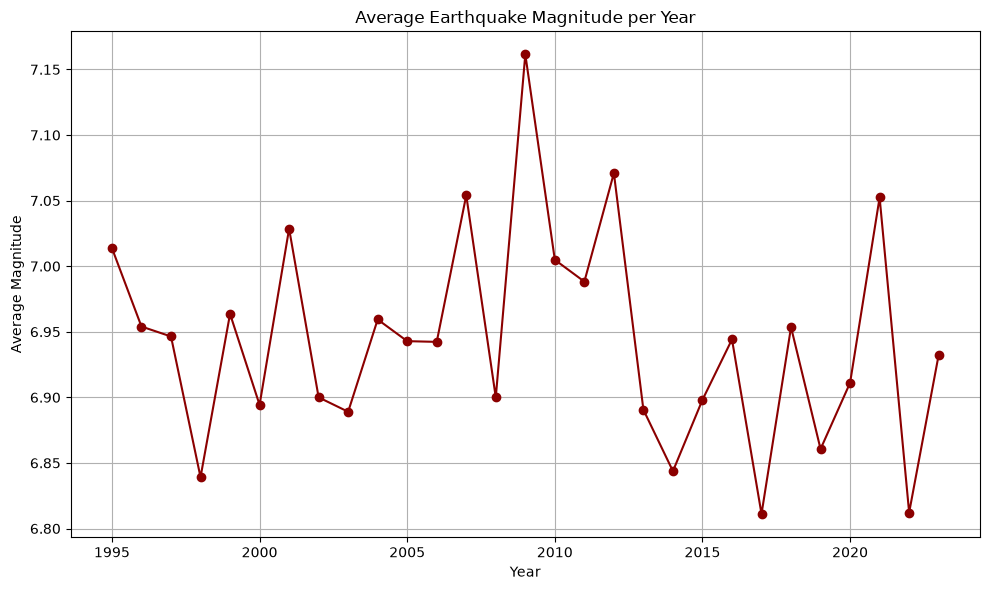

year
1995    7.013793
1996    6.954000
1997    6.946429
1998    6.839130
1999    6.963636
2000    6.894286
2001    7.028571
2002    6.900000
2003    6.889032
2004    6.959375
2005    6.942857
2006    6.942308
2007    7.054054
2008    6.900000
2009    7.161538
2010    7.004878
2011    6.988235
2012    7.070968
2013    6.890566
2014    6.843750
2015    6.898113
2016    6.944186
2017    6.811111
2018    6.953488
2019    6.860606
2020    6.911111
2021    7.052381
2022    6.812195
2023    6.932353
Name: magnitude, dtype: float64


In [7]:
yearly_avg = df.groupby('year')['magnitude'].mean()

plt.figure(figsize=(10,6))
yearly_avg.plot(kind='line', marker='o', color='darkred')
plt.title('Average Earthquake Magnitude per Year')
plt.xlabel('Year')
plt.ylabel('Average Magnitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('line_yearly_avg.png', dpi=300, bbox_inches='tight')
plt.show()

print(yearly_avg)

**Conclusion:** Average earthquake magnitude fluctuates year to year rather than showing a steady upward or downward trend, suggesting no strong long-term pattern in earthquake strength over this period — variation is more likely driven by which specific major events occurred in each year.

## Overall Summary

This assignment visualized the earthquake dataset (1995–2023) using five different plot types:
- **Bar Plot** showed earthquake counts vary significantly by continent, linked to tectonic activity zones.
- **Histogram** revealed most earthquakes occur at shallow depths, with a rare secondary cluster at deep-focus levels.
- **Pie Chart** showed tsunamis are triggered by only a small fraction of earthquakes.
- **Scatter Plot** confirmed a strong positive relationship between magnitude and significance.
- **Line Plot** showed no clear long-term trend in average magnitude, indicating yearly fluctuation driven by individual major events.

Together, these visualizations highlight key spatial, temporal, and magnitude-related patterns in global earthquake activity over the studied period.